# Robust Group Comparisons

Replaces the Week 2 Welch *t*-test / one-way ANOVA (on raw, heavy-tailed revenue) and the single chi-square test with:

| Week 2 | Week 3 |
|---|---|
| Welch t-test on raw revenue | Mann–Whitney U + **Cliff's δ** and **median ratio** with bootstrap CIs |
| One-way ANOVA | **Kruskal–Wallis** (ε² effect size) + **Dunn** post-hoc (Holm); Welch ANOVA + **Games–Howell** on log10 revenue as a parametric cross-check |
| Chi-square, one binning, `0` counted as a review tier | Chi-square on scored games, **Cramér's V**, permutation p-value, **binning sensitivity** |
| 5 tests, no correction | One **Holm-adjusted family** |

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))  # project root: import via the src package so src/statistics.py cannot shadow the stdlib module
from src import statistics as rs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4g}".format
pd.options.display.width = 140

df = rs.load_robust()
CLS = rs.CLASS_ORDER
PAL = rs.CLASS_COLORS
print(f"n = {len(df):,}  |  columns = {df.shape[1]}")

n = 1,500  |  columns = 20


In [2]:
import pingouin as pg
import scikit_posthocs as sp

OUTCOMES = {"revenue": "revenue", "copiesSold": "copiesSold", "price": "price",
            "avgPlaytime": "avgPlaytime", "reviewScore": "reviewScore_clean"}
PAIRS = [("AA", "Indie"), ("AAA", "Indie"), ("AAA", "AA")]
N_BOOT = 1000
rng = np.random.default_rng(rs.RNG_SEED)

## 1. What Week 2 got wrong on the AAA-vs-Indie question

Week 2 reported "AAA vs Indie revenue: not significant (Welch p = 0.104)" *and* "ANOVA significant (p < 0.001)" and explained the disagreement by group variance. The disagreement is an artefact of comparing **means** of a variable whose mean is ~24× its median. Same question, four methods:

In [3]:
a = df.loc[df.publisherClass == "AAA", "revenue"]; i = df.loc[df.publisherClass == "Indie", "revenue"]
la = df.loc[df.publisherClass == "AAA", "log_revenue"]; li = df.loc[df.publisherClass == "Indie", "log_revenue"]
w2 = stats.ttest_ind(a, i, equal_var=False)
w3 = stats.ttest_ind(la, li, equal_var=False)
mw = stats.mannwhitneyu(a, i, alternative="two-sided")
d_ = rs.cliffs_delta(a, i)
contrast = pd.DataFrame([
    ["Welch t, raw revenue  (Week 2)", "difference in means", f"t = {w2.statistic:.2f}", w2.pvalue],
    ["Welch t, log10 revenue", "ratio of geometric means", f"t = {w3.statistic:.2f}", w3.pvalue],
    ["Mann-Whitney U", "stochastic dominance", f"U = {mw.statistic:,.0f}", mw.pvalue],
    ["Cliff's delta", "P(AAA>Indie) - P(AAA<Indie)", f"delta = {d_:+.2f} ({rs.cliffs_label(d_)})", np.nan],
], columns=["method", "estimand", "statistic", "p"])
print(f"Geometric-mean ratio AAA/Indie = {10 ** (la.mean() - li.mean()):.1f}x  |  median ratio = {a.median() / i.median():.1f}x")
contrast

Geometric-mean ratio AAA/Indie = 7.9x  |  median ratio = 10.2x


,method,estimand,statistic,p
0,"Welch t, raw revenue (Week 2)",difference in means,t = 1.66,0.1039
1,"Welch t, log10 revenue",ratio of geometric means,t = 6.22,8.342e-08
2,Mann-Whitney U,stochastic dominance,"U = 52,280",2.652e-11
3,Cliff's delta,P(AAA>Indie) - P(AAA<Indie),delta = +0.54 (large),NaN


Under the raw-mean Welch test a handful of Indie and AAA blockbusters dominate both variances and mask the difference; every method that is not driven by the extreme tail finds a clear, sizeable AAA advantage. **The Week 2 conclusion "AAA vs Indie revenue difference not significant" should be replaced by this result.**

## 2. Kruskal–Wallis across publisher classes (Holm-adjusted across the 5 outcomes)

In [4]:
rows = []
for name, col in OUTCOMES.items():
    d = df[[col, "publisherClass"]].dropna()
    groups = [d.loc[d.publisherClass == c, col].values for c in CLS]
    H, p = stats.kruskal(*groups)
    rows.append({"outcome": name, "n": len(d), "H": H, "df": 2, "p_raw": p, "epsilon2": rs.epsilon_squared(H, len(d)),
                 **{f"median_{c}": np.median(g) for c, g in zip(CLS, groups)}})
kw = pd.DataFrame(rows)
kw["p_holm"] = pg.multicomp(kw.p_raw.values, method="holm")[1]
kw["reject_holm_.05"] = kw.p_holm < .05
rs.save_table(kw, "robust_kruskal_wallis.csv")
kw

,outcome,n,H,df,p_raw,epsilon2,median_Indie,median_AA,median_AAA,p_holm,reject_holm_.05
0,revenue,1500,129,2,9.717e-29,0.08606,9.077e+04,6.722e+05,9.289e+05,3.887e-28,True
1,copiesSold,1500,71.75,2,2.624e-16,0.04787,1.021e+04,3.068e+04,4.316e+04,7.871e-16,True
2,price,1500,141.2,2,2.226e-31,0.09417,14.99,29.99,29.99,1.113e-30,True
3,avgPlaytime,1500,57.94,2,2.623e-13,0.03865,6.331,11.2,11.94,5.246e-13,True
4,reviewScore,1401,3.149,2,0.2071,0.002249,85,84,84,0.2071,False


Effect-size guide for ε² (rank-eta-squared): < 0.01 negligible, 0.01–0.06 small, 0.06–0.14 medium, > 0.14 large.

## 3. Post-hoc pairwise comparisons: Dunn (Holm), Cliff's δ, median ratio

In [5]:
def boot_pair(x, y, n=N_BOOT):
    """Percentile bootstrap CIs for Cliff's delta and the ratio of medians."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    deltas, ratios = [], []
    for _ in range(n):
        xs, ys = rng.choice(x, len(x)), rng.choice(y, len(y))
        deltas.append(rs.cliffs_delta(xs, ys))
        ratios.append(np.median(xs) / np.median(ys))
    return np.percentile(deltas, [2.5, 97.5]), np.percentile(ratios, [2.5, 97.5])

rows = []
for name in ["revenue", "copiesSold", "price", "avgPlaytime"]:
    col = OUTCOMES[name]
    d = df[[col, "publisherClass"]].dropna()
    d = d[d[col] > 0] if name in ("price", "avgPlaytime") else d      # positives only so median ratios are defined
    dunn = sp.posthoc_dunn(d, val_col=col, group_col="publisherClass", p_adjust="holm")
    for g1, g2 in PAIRS:
        x, y = d.loc[d.publisherClass == g1, col], d.loc[d.publisherClass == g2, col]
        dl = rs.cliffs_delta(x, y)
        (dlo, dhi), (rlo, rhi) = boot_pair(x, y)
        rows.append({"outcome": name, "contrast": f"{g1} vs {g2}", "n1": len(x), "n2": len(y),
                     "median_1": x.median(), "median_2": y.median(),
                     "median_ratio": x.median() / y.median(), "ratio_lo": rlo, "ratio_hi": rhi,
                     "cliffs_delta": dl, "delta_lo": dlo, "delta_hi": dhi, "magnitude": rs.cliffs_label(dl),
                     "p_dunn_holm": dunn.loc[g1, g2]})
pairwise = pd.DataFrame(rows)
rs.save_table(pairwise, "robust_pairwise_posthoc.csv")
pairwise[["outcome", "contrast", "median_1", "median_2", "median_ratio", "ratio_lo", "ratio_hi",
          "cliffs_delta", "delta_lo", "delta_hi", "magnitude", "p_dunn_holm"]]

,outcome,contrast,median_1,median_2,median_ratio,ratio_lo,ratio_hi,cliffs_delta,delta_lo,delta_hi,magnitude,p_dunn_holm
0,revenue,AA vs Indie,6.722e+05,9.077e+04,7.405,4.72,9.932,0.4834,0.3983,0.5614,large,3.23e-21
1,revenue,AAA vs Indie,9.289e+05,9.077e+04,10.23,5.71,14.65,0.5444,0.3861,0.6822,large,4.119e-11
2,revenue,AAA vs AA,9.289e+05,6.722e+05,1.382,0.7843,2.415,0.09168,-0.1017,0.2608,negligible,0.4858
3,copiesSold,AA vs Indie,3.068e+04,1.021e+04,3.004,2.133,4.7,0.3049,0.2087,0.4075,small,2.263e-09
4,copiesSold,AAA vs Indie,4.316e+04,1.021e+04,4.226,2.644,6.198,0.5168,0.3927,0.6285,large,1.188e-09
5,copiesSold,AAA vs AA,4.316e+04,3.068e+04,1.407,0.7312,2.311,0.1515,-0.01351,0.3059,small,0.02876
6,price,AA vs Indie,29.99,14.99,2.001,1.667,2.001,0.5888,0.4979,0.6772,large,9.011e-30
7,price,AAA vs Indie,39.99,14.99,2.668,2.001,3.335,0.5557,0.3365,0.7492,large,1.424e-10
8,price,AAA vs AA,39.99,29.99,1.333,1,2,0.2252,-0.01432,0.4509,small,0.9933
9,avgPlaytime,AA vs Indie,11.2,6.331,1.77,1.378,2.047,0.316,0.2278,0.3981,small,1.084e-09


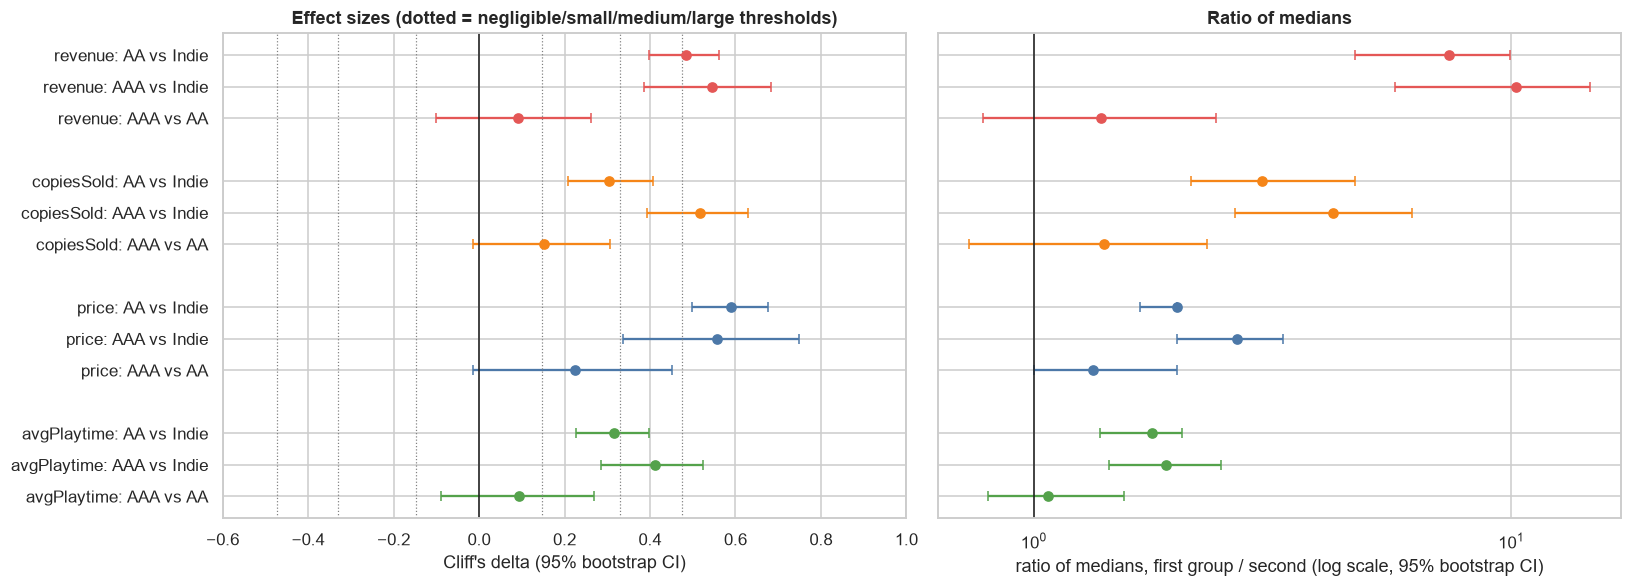

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = {"revenue": "#E45756", "copiesSold": "#F58518", "price": "#4C78A8", "avgPlaytime": "#54A24B"}
ypos = {}
k = 0
for name in colors:
    for cst in [f"{a} vs {b}" for a, b in PAIRS]:
        ypos[(name, cst)] = k; k += 1
    k += 1
for _, r_ in pairwise.iterrows():
    y = ypos[(r_.outcome, r_.contrast)]
    axes[0].errorbar(r_.cliffs_delta, y, xerr=[[r_.cliffs_delta - r_.delta_lo], [r_.delta_hi - r_.cliffs_delta]], fmt="o", color=colors[r_.outcome], capsize=3)
    axes[1].errorbar(r_.median_ratio, y, xerr=[[r_.median_ratio - r_.ratio_lo], [r_.ratio_hi - r_.median_ratio]], fmt="o", color=colors[r_.outcome], capsize=3)
labels = [f"{n}: {c}" for (n, c) in ypos]
for ax in axes:
    ax.set_yticks(list(ypos.values())); ax.set_yticklabels(labels if ax is axes[0] else [])
    ax.invert_yaxis()
for v in (.147, .33, .474):
    axes[0].axvline(v, color="grey", ls=":", lw=.8); axes[0].axvline(-v, color="grey", ls=":", lw=.8)
axes[0].axvline(0, color="k", lw=1); axes[0].set_xlim(-.6, 1); axes[0].set_xlabel("Cliff's delta (95% bootstrap CI)")
axes[0].set_title("Effect sizes (dotted = negligible/small/medium/large thresholds)")
axes[1].axvline(1, color="k", lw=1); axes[1].set_xscale("log"); axes[1].set_xlabel("ratio of medians, first group / second (log scale, 95% bootstrap CI)")
axes[1].set_title("Ratio of medians")
fig.tight_layout(); rs.save_fig(fig, "r04_effect_size_forest.png"); plt.show()

## 4. Parametric cross-check on the log scale: Welch ANOVA + Games–Howell

On log10 revenue the data are far better behaved, so a variance-robust parametric analysis is defensible as a *confirmation* (not the primary test).

In [7]:
wa = pg.welch_anova(data=df, dv="log_revenue", between="publisherClass")
print("Welch ANOVA on log10 revenue"); print(wa.round(6).to_string(index=False))
gh = pg.pairwise_gameshowell(data=df, dv="log_revenue", between="publisherClass")
gh["ratio_of_geo_means"] = 10 ** gh["diff"]
print("\nGames-Howell (diff is in log10 units; ratio_of_geo_means = 10^diff, A over B)")
gh.round(6)

Welch ANOVA on log10 revenue
        Source  ddof1  ddof2     F  p_unc    np2
publisherClass      2  105.6 60.11      0 0.1253

Games-Howell (diff is in log10 units; ratio_of_geo_means = 10^diff, A over B)


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,ratio_of_geo_means
0,Indie,AA,5.132,5.867,-0.7349,0.07949,-9.246,161.1,0,-1.073,0.1841
1,Indie,AAA,5.132,6.028,-0.8958,0.1441,-6.218,52.64,0,-1.339,0.1271
2,AA,AAA,5.867,6.028,-0.1609,0.1626,-0.9898,82.8,0.5853,-0.1668,0.6904


## 5. Chi-square: publisher class × review tier — replicate, repair, stress-test

Week 2's χ² = 6.65 (p = 0.155) placed **`reviewScore == 0` games in the lowest ("Mixed") tier**. Those 99 games have no score (notebook 01), so the tier counts were contaminated. Below: replication, the corrected test, and sensitivity to the arbitrary cut-points.

In [8]:
def tier(scores, cuts):
    edges = [-np.inf, *cuts, np.inf]
    return pd.cut(scores, edges, right=False, labels=["Low", "Mid", "High"][:len(cuts) + 1])

def chi_row(label, cls, t):
    tab = pd.crosstab(cls, t)
    chi2, p, dof, exp = stats.chi2_contingency(tab, correction=False)
    obs, pperm = rs.permutation_chi2(cls, t, n_perm=5000)
    return {"scheme": label, "n": int(tab.values.sum()), "chi2": chi2, "df": dof, "p_asymptotic": p,
            "p_permutation": pperm, "cramers_v": rs.cramers_v(tab), "min_expected": exp.min()}

scored = df.dropna(subset=["reviewScore_clean"])
q1, q2 = scored.reviewScore_clean.quantile([1 / 3, 2 / 3])
rows = [
    chi_row("Week 2 replica (0 counted as lowest tier; cuts 70/90)", df.publisherClass, tier(df.reviewScore, [70, 90])),
    chi_row("Scored games only; cuts 70/90", scored.publisherClass, tier(scored.reviewScore_clean, [70, 90])),
    chi_row("Scored only; cuts 60/85", scored.publisherClass, tier(scored.reviewScore_clean, [60, 85])),
    chi_row("Scored only; cuts 75/90", scored.publisherClass, tier(scored.reviewScore_clean, [75, 90])),
    chi_row(f"Scored only; data-driven terciles ({q1:.0f}/{q2:.0f})", scored.publisherClass, tier(scored.reviewScore_clean, [q1, q2])),
]
chi_tbl = pd.DataFrame(rows)
rs.save_table(chi_tbl, "robust_chi_square_sensitivity.csv")
chi_tbl

,scheme,n,chi2,df,p_asymptotic,p_permutation,cramers_v,min_expected
0,Week 2 replica (0 counted as lowest tier; cuts...,1500,6.653,4,0.1554,0.1528,0.02974,11.09
1,Scored games only; cuts 70/90,1401,8.296,4,0.0813,0.08158,0.03917,7.729
2,Scored only; cuts 60/85,1401,4.581,4,0.3331,0.3217,0.01437,4.022
3,Scored only; cuts 75/90,1401,8.275,4,0.08201,0.07958,0.03907,11.65
4,Scored only; data-driven terciles (79/90),1401,3.377,4,0.4968,0.4937,0,16.16


In [9]:
print("Contingency table, scored games, cuts 70/90 (row %):")
tab = pd.crosstab(scored.publisherClass, tier(scored.reviewScore_clean, [70, 90]))
print(tab.to_string()); print((tab.div(tab.sum(1), axis=0) * 100).round(1).to_string())

# Is having a score at all related to publisher class?
tab2 = pd.crosstab(df.publisherClass, df.has_review)
chi2_2, p2, dof2, exp2 = stats.chi2_contingency(tab2, correction=False)
print(f"\nhas_review x publisherClass: chi2 = {chi2_2:.2f}, df = {dof2}, p = {p2:.3f}, Cramer's V = {rs.cramers_v(tab2):.3f}")

Contingency table, scored games, cuts 70/90 (row %):
reviewScore_clean  Low  Mid  High
publisherClass                   
Indie              180  623   414
AA                  28   60    47
AAA                 13   21    15
reviewScore_clean  Low  Mid  High
publisherClass                   
Indie             14.8 51.2    34
AA                20.7 44.4  34.8
AAA               26.5 42.9  30.6

has_review x publisherClass: chi2 = 0.28, df = 2, p = 0.871, Cramer's V = 0.000


## 6. One multiplicity family (Holm)

In [10]:
fam = kw[["outcome", "p_raw"]].copy()
fam["test"] = "Kruskal-Wallis: " + fam.outcome
fam = fam[["test", "p_raw"]]
chi_main = chi_tbl.iloc[1]
fam.loc[len(fam)] = ["Chi-square: class x review tier (70/90, scored only)", chi_main.p_asymptotic]
fam.loc[len(fam)] = ["Chi-square: class x has_review", p2]
fam["p_holm"] = pg.multicomp(fam.p_raw.values, method="holm")[1]
fam["significant_holm_.05"] = fam.p_holm < .05
rs.save_table(fam, "hypothesis_tests_robust.csv")
fam

,test,p_raw,p_holm,significant_holm_.05
0,Kruskal-Wallis: revenue,9.717e-29,5.83e-28,True
1,Kruskal-Wallis: copiesSold,2.624e-16,1.312e-15,True
2,Kruskal-Wallis: price,2.226e-31,1.558e-30,True
3,Kruskal-Wallis: avgPlaytime,2.623e-13,1.049e-12,True
4,Kruskal-Wallis: reviewScore,0.2071,0.4143,False
5,"Chi-square: class x review tier (70/90, scored...",0.0813,0.2439,False
6,Chi-square: class x has_review,0.8712,0.8712,False


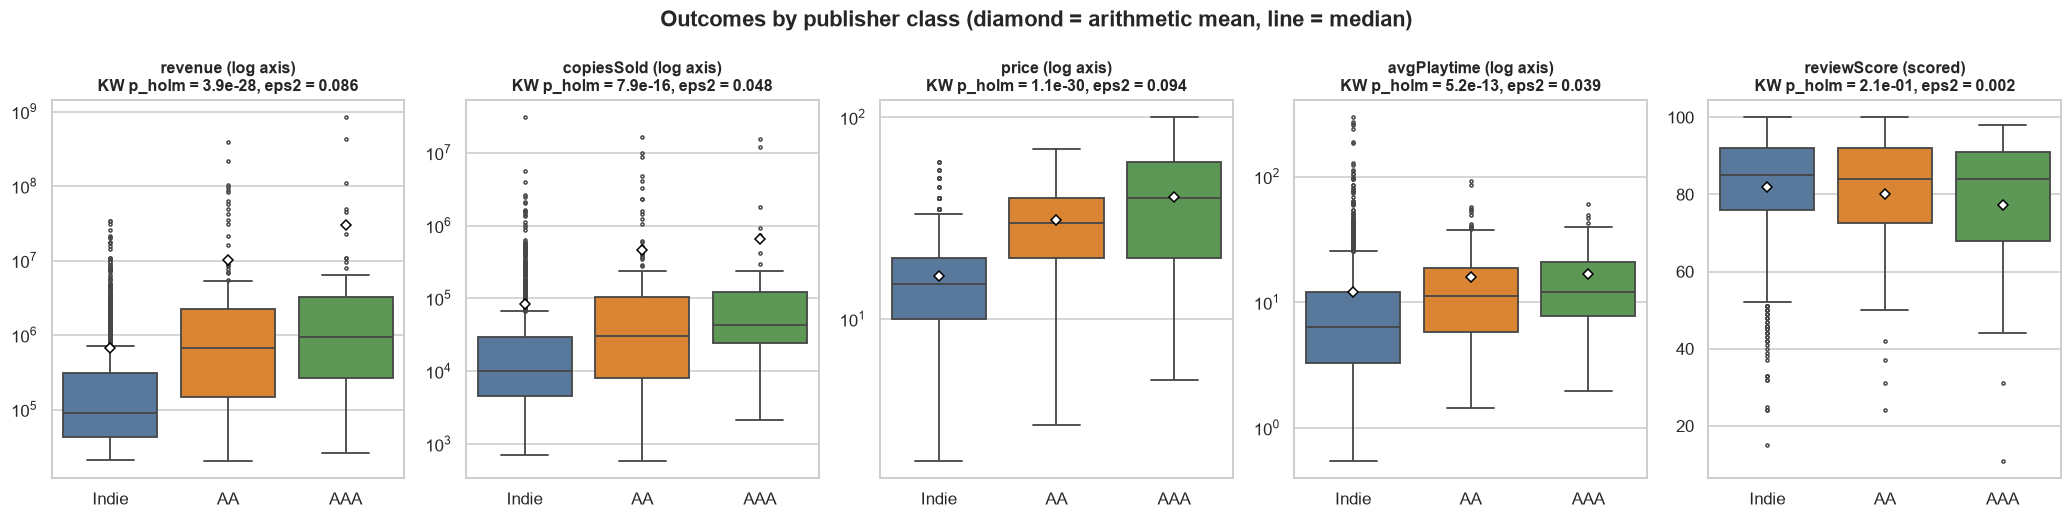

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4.8))
for ax, (name, col) in zip(axes, OUTCOMES.items()):
    d = df[[col, "publisherClass"]].dropna()
    if name != "reviewScore":
        d = d[d[col] > 0]
    sns.boxplot(data=d, x="publisherClass", y=col, order=CLS, palette=PAL, ax=ax, fliersize=2, linewidth=1.2, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5))
    if name != "reviewScore":
        ax.set_yscale("log")
    p_ = kw.loc[kw.outcome == name, "p_holm"].iloc[0]; e_ = kw.loc[kw.outcome == name, "epsilon2"].iloc[0]
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(f"{name}" + (" (log axis)" if name != "reviewScore" else " (scored)") + f"\nKW p_holm = {p_:.1e}, eps2 = {e_:.3f}", fontsize=10.5)
fig.suptitle("Outcomes by publisher class (diamond = arithmetic mean, line = median)", fontweight="bold")
fig.tight_layout(); rs.save_fig(fig, "r04_boxplots_by_class.png"); plt.show()